# Test: Morphology operations

This notebook tests geodesic dilation implementation using it to perform Reconstruction by Dilation

## Import libraries

Assures that the harpia module has already been compiled with cython, before (command: python3 setup.py)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# workaround to allow importing harpia python module
import sys

sys.path.append("../../")
from harpia.morphology.operations_binary import erosion_binary, dilation_binary, reconstruction_binary, fill_holes
from harpia.morphology.operations_grayscale import erosion_grayscale
from harpia.common.size import Size

import harpia.morphology.operations_binary as harpia

In [2]:
def contiguous(array: np.ndarray) -> np.ndarray:
    if not array.flags["C_CONTIGUOUS"]:
        array = np.ascontiguousarray(array.astype(array.type()))

In [3]:
# test if all functions were imported
help(harpia)

Help on module harpia.morphology.operations_binary in harpia.morphology:

NAME
    harpia.morphology.operations_binary

FUNCTIONS
    closing_binary(hostImage, kernel, hostOutput=None, verbose=0, gpu=True)
    
    dilation_binary(hostImage, kernel, hostOutput=None, verbose=0, gpu=True)
    
    erosion_binary(hostImage, kernel, hostOutput=None, verbose=0, gpu=True)
    
    fill_holes(hostImage, hostOutput=None, verbose=0, gpu=True)
    
    geodesic_dilation_binary(hostImage, hostMask, hostOutput=None, verbose=0, gpu=True)
    
    geodesic_erosion_binary(hostImage, hostMask, hostOutput=None, verbose=0, gpu=True)
    
    opening_binary(hostImage, kernel, hostOutput=None, verbose=0, gpu=True)
    
    reconstruction_binary(hostImage, hostMask, operation, hostOutput=None, verbose=0, gpu=True)

DATA
    __test__ = {}

FILE
    /home/camila.araujo/Documents/harpia/harpia/morphology/operations_binary.cpython-310-x86_64-linux-gnu.so





## Framework

Useful functions to test harpia module

In [4]:
def get_vertical_line_kernel():
    kernel = np.array([[1, 0, 0], [1, 0, 0], [1, 0, 0]], dtype=np.int32)
    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
    return kernel


def get_horizontal_line_kernel():
    kernel = np.array([[1, 1, 1], [0, 0, 0], [0, 0, 0]], dtype=np.int32)
    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
    return kernel


def get_kernel():
    kernel = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=np.int32)
    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
    return kernel

In [5]:
def read_input_uint16(filename, xsize, ysize, zsize, verbose=True):
    raw_data = np.fromfile(filename, dtype=np.uint16)
    raw_data = raw_data.astype(np.int32)

    # Check the size of the data
    if raw_data.size != xsize * ysize * zsize:
        raise ValueError(
            f"Expected {xsize * ysize * zsize} elements, but got {raw_data.size} elements."
        )
    
    # Reshape the data into the correct dimensions
    #xsize é o númeor de elementos na direção x, equivale ao númeor de 'colunas' que é a segunda dimensão para o ndarray
    image = raw_data.reshape((ysize, xsize, zsize))
    
    if(verbose):
        print("input (ysize,xsize,zsize): ", image.shape)
        
    return image


In [6]:
def show(image, output):
    # Plot the original and the processed images
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(output, cmap="gray")
    axes[1].set_title("Processed Image")
    axes[1].axis("off")

## Read Input Image

In [7]:
image = read_input_uint16("../../example_images/binary/blobs_355x321x1_16b.raw", 355,321,1)
flag_verbose = True

input (ysize,xsize,zsize):  (321, 355, 1)


In [8]:
help(erosion_binary)

Help on fused_cython_function in module harpia.morphology.operations_binary:

erosion_binary(hostImage, kernel, hostOutput=None, verbose=0, gpu=True)



## TEST: grayscale == binary?

True

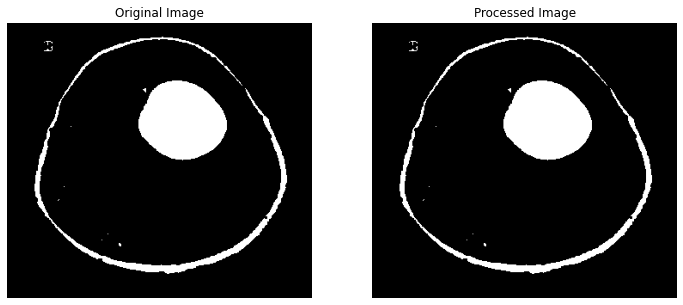

In [9]:
out_binary = erosion_binary(
    hostImage=image,
    kernel=get_kernel(),
)

out_gray = erosion_grayscale(
    hostImage=image,
    kernel=get_kernel(),
)

show(out_binary, out_gray)
(out_binary == out_gray).all()

False

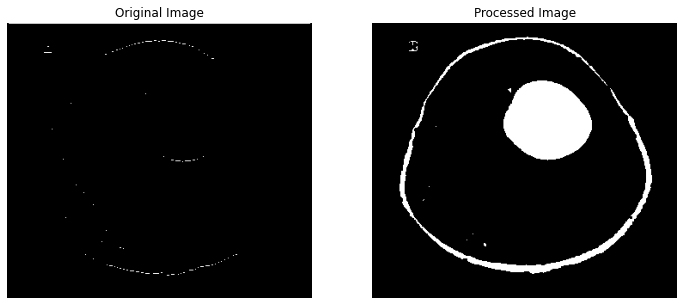

In [10]:
out_binary = erosion_binary(
    hostImage=image,
    kernel=get_horizontal_line_kernel(),
)

out_gray = erosion_grayscale(
    hostImage=image,
    kernel=get_horizontal_line_kernel(),
)

show(out_binary, out_gray)
(out_binary == out_gray).all()

## Reconstruction by Dilation

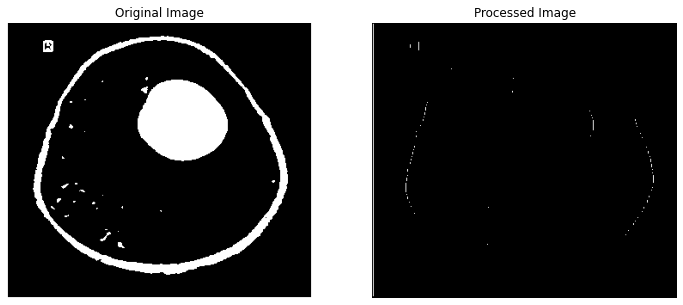

In [11]:
# Obtain the marker image
marker = erosion_binary(
    hostImage=image,
    kernel=get_vertical_line_kernel(),
)
show(image, marker)

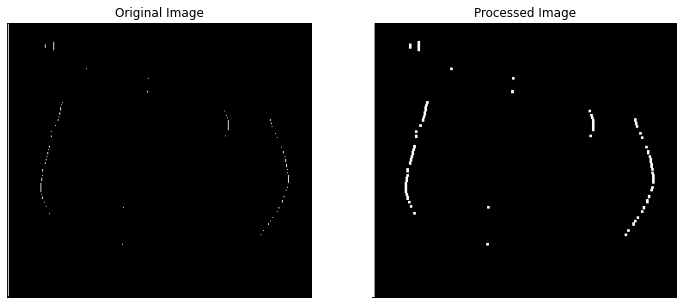

In [12]:
# Dilation
marker_dilated = dilation_binary(
    marker,
    get_kernel(),
)
show(marker, marker_dilated)

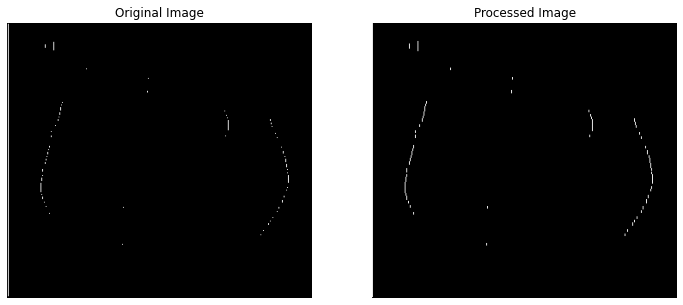

In [13]:
# Geodesic dilation (one step)
marker_geo_dilated = harpia.geodesic_dilation_binary(
    marker, image
)
show(marker, marker_geo_dilated)

GOT IT:  515


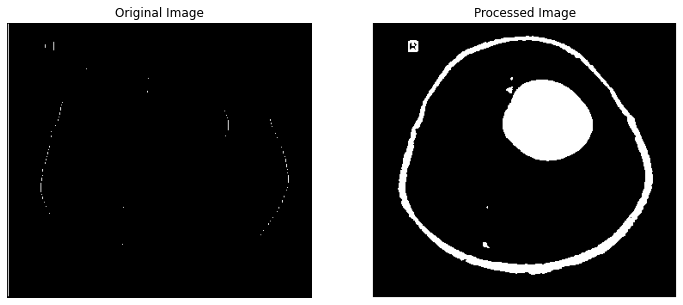

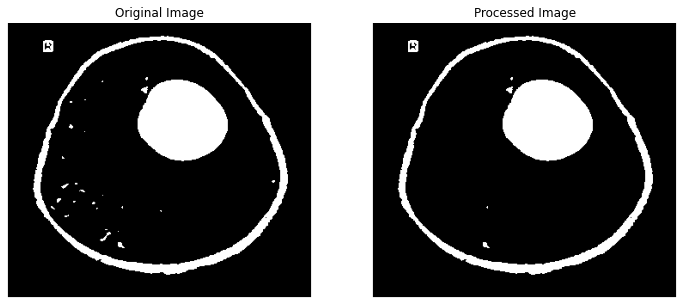

In [18]:
# Reconstruction by dilation to test geodesic dilation correctness

marker_input = marker
count = 0
for i in range(1000):
    output_aux = harpia.geodesic_dilation_binary(
        marker_input, image
    )
    count += 1
    if (marker_input == output_aux).all():
        print("GOT IT: ", count)
        break
    else:
        marker_input = output_aux
output = marker_input
show(marker, output)
show(image, output)

## Reconstruction complete

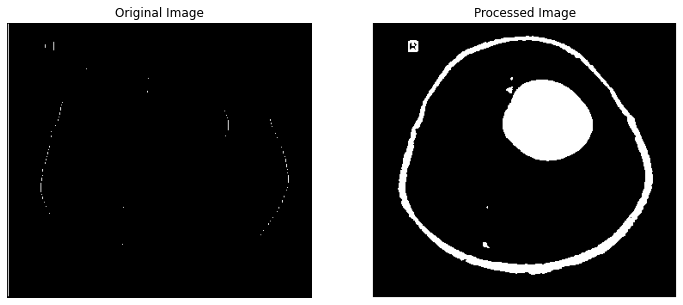

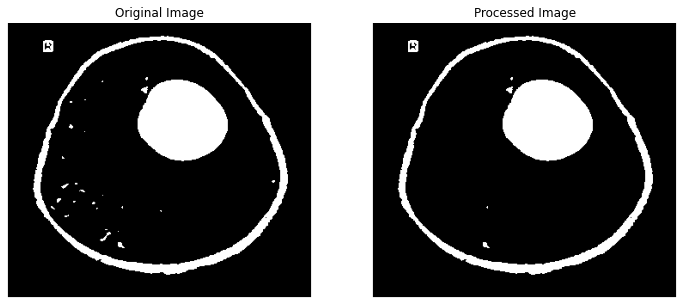

In [19]:
# Reconstruction by dilation complete
output_aux = reconstruction_binary(
    marker, image, 1
)

show(marker, output_aux)
show(image, output_aux)

input (ysize,xsize,zsize):  (183, 275, 1)


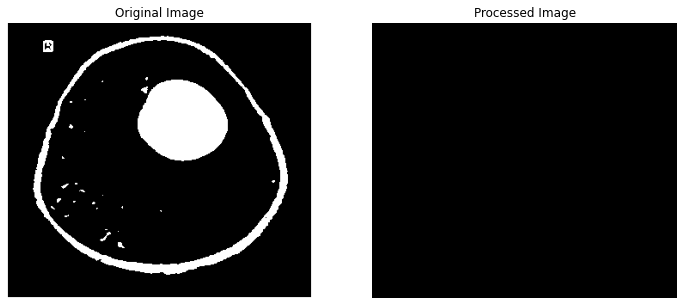

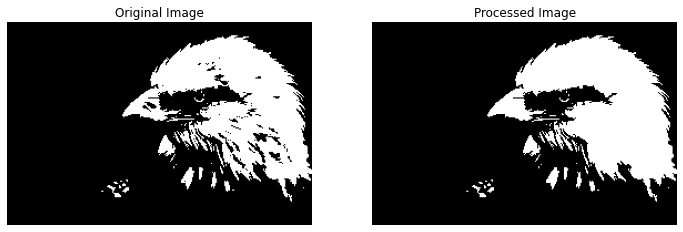

In [17]:
# Fill Holes
out = fill_holes(image)
show(image, out) #this image has a white border, so the intire image is a big 'hole'

image2 = read_input_uint16("../../example_images/binary/eagle_275x183x1_16b.raw", 275,183,1)
out2 = fill_holes(image2)
show(image2, out2) 